In [1]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.interference_models.pca import loo_pca, malinowski_ind, pca
from vebir.absorbance_estimators.ebs import EBS
from vebir.absorbance_estimators.veb import VEB, norm_cdf, norm_pdf, pinball_loss, als_loss, pb_map, als_map
from vebir.utils.metrics import compute_correlation_metrics, correlation_metrics_to_df
import pandas as pd 

import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.optimize import minimize
import cvxpy as cp

from scipy.linalg import svd

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" 

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR / "raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

CO2 = ref_dict["CO2"]
H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))

del ref_dict["CO2"]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

Z = np.array(blanks_dict["2011"])   
chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z)
#W = W[:, :chat_cv]

In [9]:
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "veb" / "pb"

with open(CORRECTIONS_DIR /  "loo_blanks_sigma_tau.pkl", "rb") as f:
        blank_corrections_dict = pickle.load(f)

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)

In [ ]:
# CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "map_cv" / "pb"


# with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
#     corrections_dict = pickle.load(f)

In [ ]:
blank_taus =np.array([e["tau"] for e in blank_corrections_dict])
blank_sigmas =np.array([e["sigma_hat"] for e in blank_corrections_dict])
blank_heights =np.array([np.max(e["absorbance"]) for e in blank_corrections_dict])

In [548]:
taus = []
sigmas = []
loads = []
heights = []
ref_cors =[]

for comp in ref_dict:
    #taus.append(np.array([e["tau"] for e in corrections_dict[comp]]))
    #loads.append(np.array([e["load"] for e in corrections_dict[comp]]))
    #sigmas.append(np.array([e["sigma_hat"] for e in corrections_dict[comp]]))
    #heights.append(np.array([np.max(e["absorbance"]) for e in corrections_dict[comp]]))
    ref_cors.append(np.array([e['ref_profile_corr'] for e in corrections_dict[comp]]))
# taus = np.concatenate(taus)
# loads = np.concatenate(loads)
# sigmas = np.concatenate(sigmas)
# heights = np.concatenate(heights)
ref_cors = np.concatenate(ref_cors)

In [149]:
blank_abs = np.array([i["absorbance"] for i in blank_corrections_dict])
so4_abs = np.array([i["absorbance"] for i in corrections_dict["Ammonium sulfate"]])
so4_loads = np.array([i["load"] for i in corrections_dict["Ammonium sulfate"]])

In [146]:
from sklearn.linear_model import LinearRegression

In [ ]:
mod = LinearRegression(fit_intercept=False)
loads = np.hstack((so4_loads, np.zeros(blank_abs.shape[0])))

In [423]:
MAC = []
pvals = []


for j in range(so4_abs.shape[1]):
    a = np.concatenate((so4_abs[:,j],blank_abs[:,j]))
    f =  np.concatenate((so4_loads, np.zeros(blank_abs.shape[0])))
    model = sm.OLS(a, f)  
    results = model.fit()
    pvals.append(results.pvalues[0])
    MAC.append(results.params[0])

    #x = np.vstack((so4_abs[:,[j]],blank_abs[:,[j]]))
    # mod.fit(loads[:, np.newaxis],x)

    # preds = mod.predict(loads[:, np.newaxis])
    # resid = loads[:, np.newaxis] - preds
    # sigma2_hat = np.sum(resid**2) / (resid.shape[0] - 1)  
    # sigma_hat = np.sqrt(sigma2_hat)

    # SE_beta = sigma_hat / np.sqrt(np.mean(loads**2))

    # beta_hat = mod.coef_[0]

    # t_stat = beta_hat / SE_beta
    # p_value = 2 * (1 - t.cdf(abs(t_stat), df=resid.shape[0]-1))
  
    # if p_value < 0.05:
    #     break  
    
    #break
  
    
   
    
pvals = np.array(pvals)
MAC = np.array(MAC)   
    

In [95]:
blank_abs = np.array([i["absorbance"] for i in blank_corrections_dict])
blank_theta = np.mean(blank_abs,axis=0)
blank_delta = np.std(blank_abs,axis=0)

In [7]:
j = 0 

In [10]:
y = np.array(raw_spectra_dict["Malonic Acid"]["raw"])[j,:]
entry = corrections_dict["Malonic Acid"][j]
nu = entry["nu"]
d = entry["d"]
theta = y - mu - W[:, :chat_cv] @ nu
delta = np.sqrt(np.sum((W[:, :chat_cv] * d) ** 2, axis=1))

In [56]:
scals_dct = {}
deltas_dct = {}
loads_dct = {}

for comp in corrections_dict:
    scals = []
    deltas = []

    for j in range(raw_spectra_dict[comp]["raw"].shape[0]):
        y = np.array(raw_spectra_dict[comp]["raw"])[j,:]
        entry = corrections_dict[comp][j]
        nu = entry["nu"]
        d = entry["d"]
        theta = y - mu - W[:, :chat_cv] @ nu
        delta = np.sqrt(np.sum((W[:, :chat_cv] * d) ** 2, axis=1))
        deltas.append(delta)
        
    
    deltas = np.array(deltas)

    for j in range(raw_spectra_dict[comp]["raw"].shape[0]):
        scal = np.sum(deltas[j,:]*deltas[0,:]) / np.sum(deltas[0,:]**2)
        scals.append(scal)
        
    scals = np.array(scals)
        
    loads = np.array([i["load"] for i in corrections_dict[comp]])
    
    scals_dct[comp] = scals
    deltas_dct[comp] = deltas   
    loads_dct[comp] = loads
        


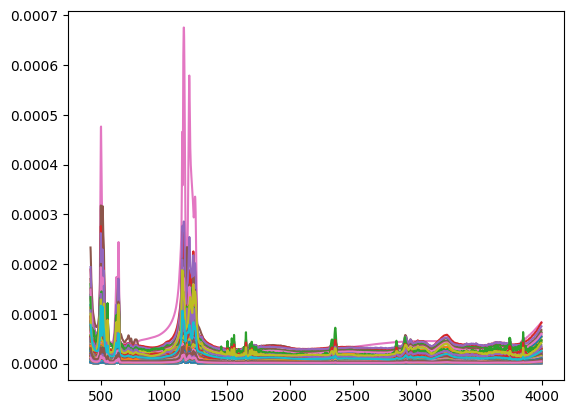

In [140]:
hold = 0
for comp in scals_dct:
    deltas = deltas_dct[comp]
    scals = scals_dct[comp]
    loads = loads_dct[comp]
    
    for j in np.arange(deltas.shape[0]):
        plt.plot(wn, deltas[j,:]/ loads[j])
    hold += 1    
#     plt.scatter(loads,scals)
# plt.xlabel("Load")
# plt.ylabel("Stdev Scaling")

In [ ]:
comp = "levoglucosan"


In [39]:
deltas = []
for j in range(raw_spectra_dict[comp]["raw"].shape[0]):
    y = np.array(raw_spectra_dict[comp]["raw"])[j,:]
    entry = corrections_dict[comp][j]
    nu = entry["nu"]
    d = entry["d"]
    theta = y - mu - W[:, :chat_cv] @ nu
    delta = np.sqrt(np.sum((W[:, :chat_cv] * d) ** 2, axis=1))
    deltas.append(delta)
deltas = np.array(deltas)
#plt.plot(wn,corrections_dict["Ammonium sulfate"][j]["absorbance"])

In [ ]:
scals = []



Text(0, 0.5, 'Stdev Scaling')

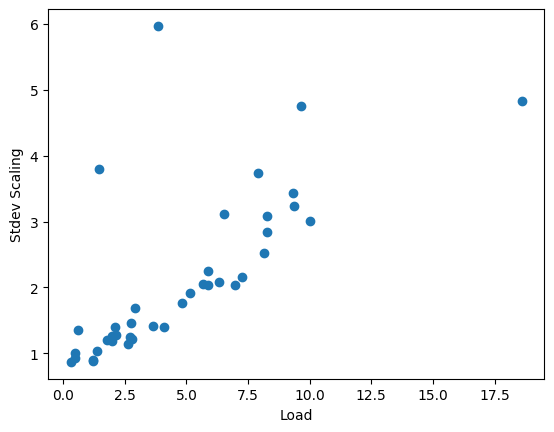

In [41]:
plt.scatter(loads,scals)
plt.xlabel("Load")
plt.ylabel("Stdev Scaling")

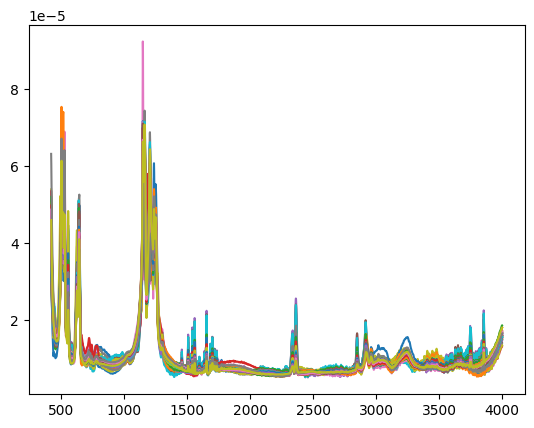

In [42]:
for j in np.arange(deltas.shape[0]):
    plt.plot(wn, deltas[j,:] / scals[j])

In [43]:
np.where(scals > 5)

(array([21]),)

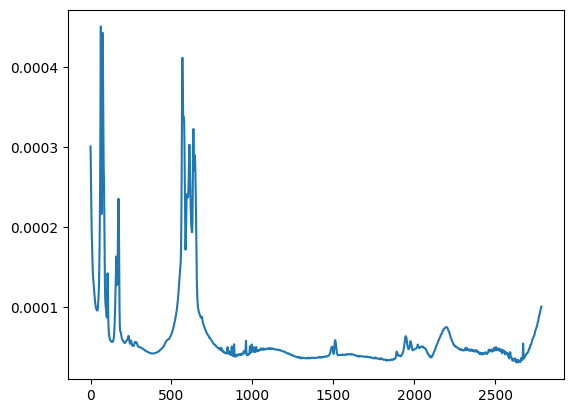

In [44]:
plt.plot(deltas[21,:])

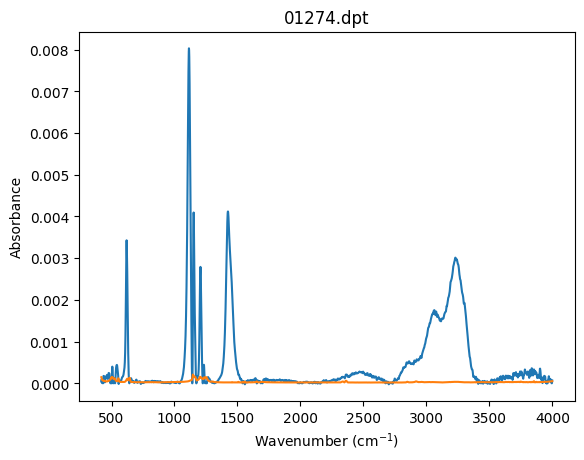

In [185]:
plt.plot(wn,corrections_dict["Ammonium sulfate"][5]["absorbance"])
plt.plot(wn,3*deltas[5,:])
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.title(corrections_dict["Ammonium sulfate"][5]["sample_id"])
plt.show()

Text(0, 0.5, 'Stdev')

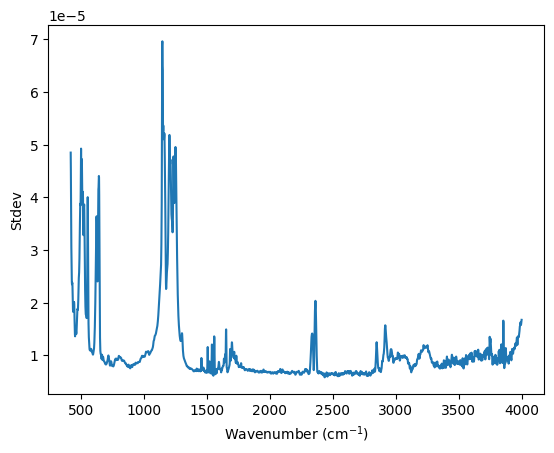

In [188]:
plt.plot(wn,deltas[5,:])
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Stdev")

In [60]:
alpha = 0.01 /2783
beta = 0.01 / 2783
zalpha = norm.ppf(1 - alpha)
zbeta = norm.ppf(1 - beta)

In [61]:
LOD = []

alpha_obs = []
beta_obs = []

for j in range(y.shape[0]):
    lb = blank_theta[j] + zalpha*blank_delta[j]
    ub = theta[j] - zbeta*delta[j]
    
    if ub >= lb:
        lod = lb
        alpha_obs.append(1-norm.cdf(lod,loc=blank_theta[j], scale=blank_delta[j]))   
        beta_obs.append(norm.cdf(lod,loc=theta[j], scale=delta[j]))   
    
    else:
        alpha_obs.append(np.nan)
        lod = np.nan
        
    LOD.append(lod)

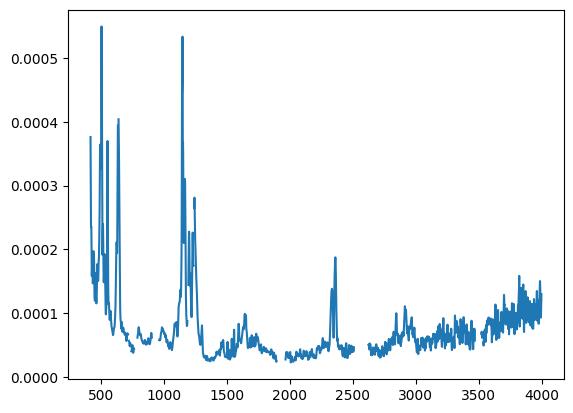

In [62]:
plt.plot(wn,LOD)

In [128]:
comp = "Ammonium sulfate"
import statsmodels.api as sm
from scipy.stats import norm

In [129]:
loads = np.array([e["load"] for e in corrections_dict[comp]])
comp_abs = np.array([e["absorbance"] for e in corrections_dict[comp]])
blank_abs = np.array([e["absorbance"] for e in blank_corrections_dict])

In [130]:
alpha = 0.01 / 2783
beta = 0.01 / 2783
zalpha = norm.ppf(1 - alpha)
zbeta = norm.ppf(1 - beta)

In [131]:
import numpy as np
from scipy.optimize import minimize

def neg_loglike(params, a, f):
    beta, log_sigma2, log_gamma = params
    
    sigma2 = np.exp(log_sigma2)
    gamma = np.exp(log_gamma)

    var = sigma2 + gamma * f**2
    resid = a - beta * f

    return 0.5 * np.sum(np.log(var) + resid**2 / var)


def fit_model(a, f):
    init = np.array([0.0, np.log(1000.0), np.log(0.1)])  # log-scale init
    result = minimize(neg_loglike, init, args=(a, f))
    
    beta, log_sigma2, log_gamma = result.x
    return {
        "beta": beta,
        "sigma2": np.exp(log_sigma2),
        "gamma": np.exp(log_gamma)
    }, result

# Example:
# params, result = fit_model(a, f)
# print(params)




In [132]:
f =  np.concatenate((loads, np.zeros(blank_abs.shape[0])))
LOD = []
MAC = []
pvals = []

for j in range(comp_abs.shape[1]):
    a = comp_abs[:,j]
    b = blank_abs[:,j]
    absorbance = np.concatenate((a, b))
    
    # model = sm.OLS(endog=abs, exog=f)  
    # results = model.fit()
    
    params, result = fit_model(absorbance, f)
    
    gamma = params["beta"]
    #resid = results.resid 
    #sigma = np.sqrt(results.mse_resid)
    #sigma = np.std(resid[a.shape[0]:])
    sigma = np.sqrt(params["sigma2"])
    
    LOD.append(sigma * (zalpha + zbeta))
    MAC.append(gamma)
    pvals.append(results.pvalues[0])
    
LOD = np.array(LOD)
LOD[LOD < 0] = 0
MAC = np.array(MAC)
pvals = np.array(pvals)

In [144]:
loads.shape

(39,)

In [133]:
params

{'beta': np.float64(0.00020317755387329648),
 'sigma2': np.float64(8.030504501916873e-10),
 'gamma': np.float64(4.6116630730780094e-08)}

In [142]:
plt.plot(wn,MAC*f)
plt.plot(wn,LOD)

ValueError: operands could not be broadcast together with shapes (2785,) (103,) 

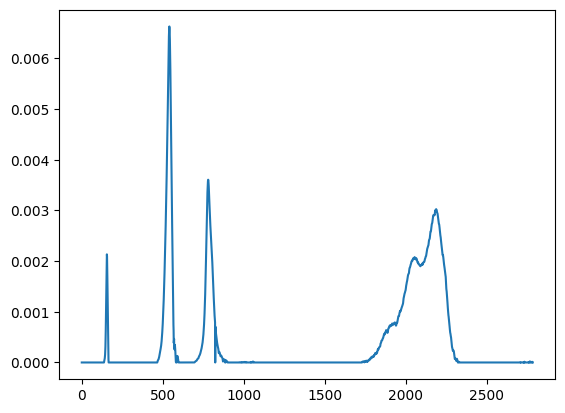

In [135]:
l = MAC - LOD
l[l < 0] = 0
plt.plot(l)

In [109]:
LOD[-1]

np.float64(0.0002544320057137294)

In [954]:
results = model.fit()

In [955]:
results.params

array([1.06399379e-03, 9.16910602e-05])

In [957]:
sigma

np.float64(0.0035172616052646264)

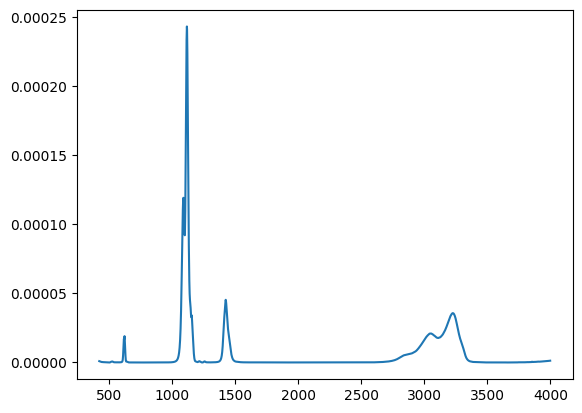

In [949]:
plt.plot(wn,LOD)

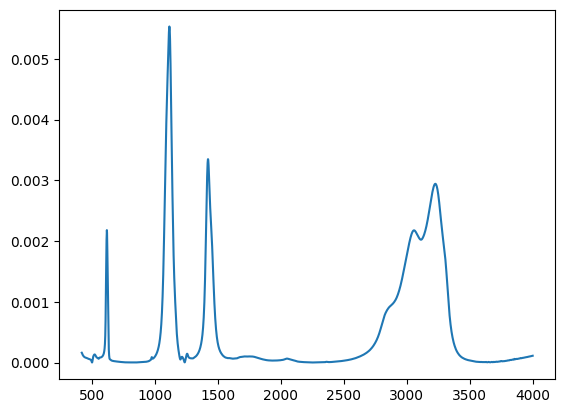

In [947]:
plt.plot(wn,MAC)

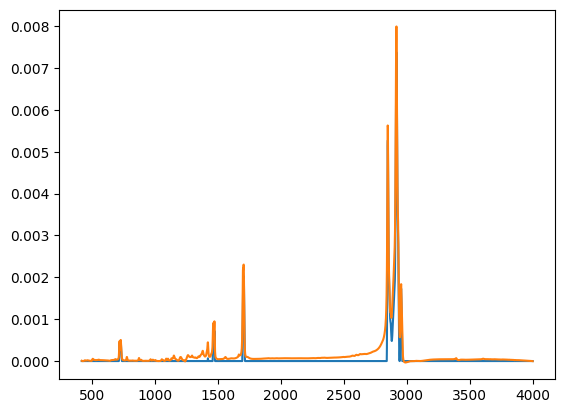

In [810]:
mac_trunc = MAC - LOD
mac_trunc[mac_trunc < 0] = 0
plt.plot(wn,mac_trunc)
plt.plot(wn,MAC)

NameError: name 'MAX' is not defined

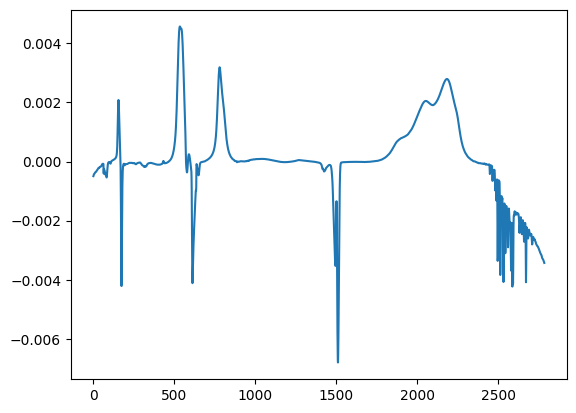

In [799]:
plt.plot(MAC - LOD)

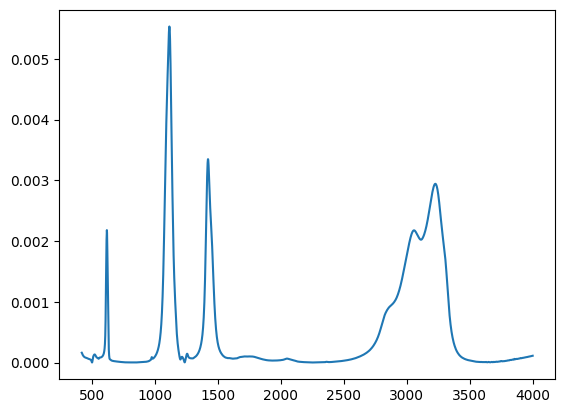

In [796]:
plt.plot(wn,MAC)

In [715]:
i = 38

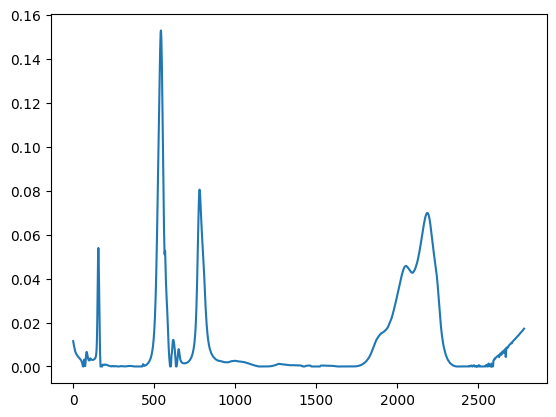

In [716]:
a = so4_abs[i,:]
a = a - LOD
a[a < 0] = 0
plt.plot(a)
#plt.plot(LOD)

In [663]:
anew = so4_abs[40,:] - LOD    

In [664]:
anew[anew < 0] = 0

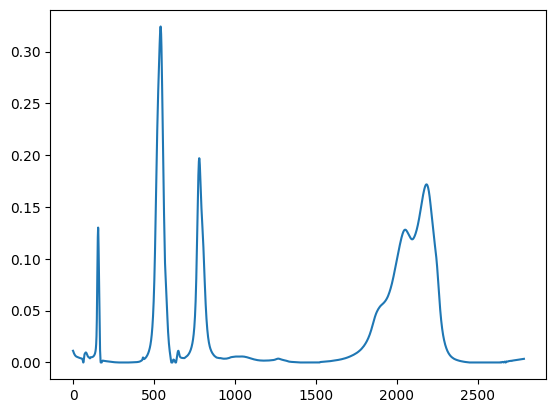

In [665]:
plt.plot(anew)

In [678]:
Ac = []
for i in range(49):
    Ac.append(so4_abs[i,:]/so4_loads[i])
    Ac[-1] = Ac[-1] - LOD
    Ac[-1][Ac[-1] < 0] = 0

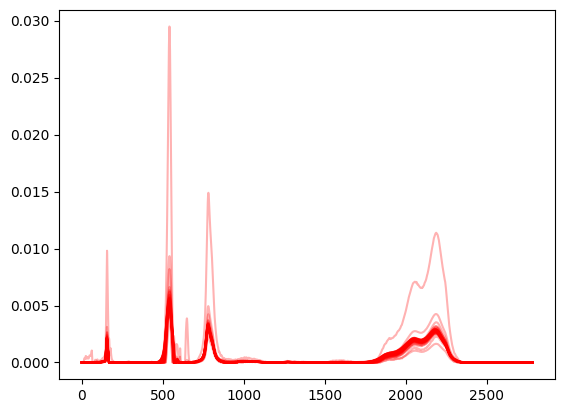

In [679]:
for i in range(49):
    plt.plot(Ac[i], color='red', alpha=0.3)

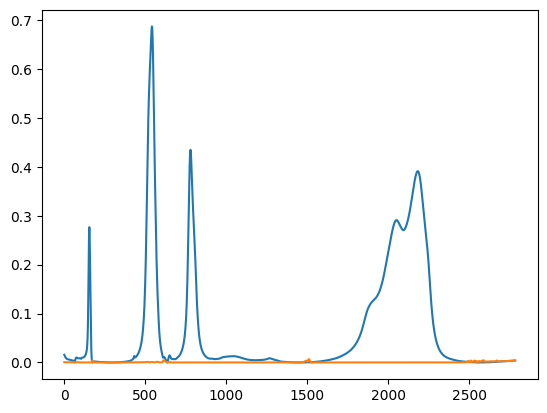

In [688]:
plt.plot(so4_abs[48,:])
plt.plot(LOD)

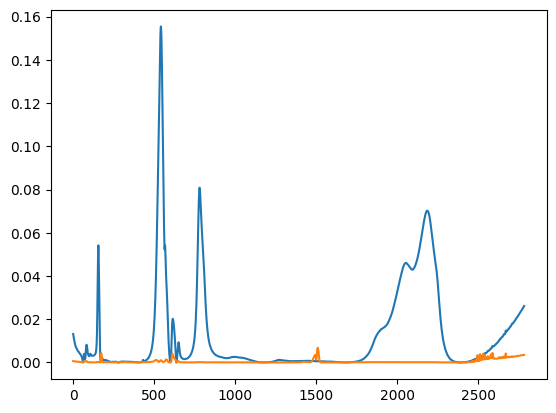

In [697]:
a = so4_abs[38,:]
plt.plot(a)
plt.plot(LOD)

In [4]:
from vebir.utils.distribute import distribute_veb

In [17]:
Z = np.array(blanks_dict["2011"])
wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z)
loss = "PB"

In [ ]:
#comp = "Malonic Acid"

In [18]:
# tau_min, tau_max = 1e-5, 0.25
# loss = "PB"

In [19]:
tau_min, tau_max = 1e-5, 0.25
corrections_dict = {}

for comp in raw_spectra_dict:
    sample_id = raw_spectra_dict[comp]["raw"].index.tolist()
    Y = np.array(raw_spectra_dict[comp]["raw"])

    distribute_args = [
                (y, mu, W[:, :chat_cv], tau_min, tau_max, loss, sid)
                for y, sid in zip(Y, sample_id)
            ]

    with mp.Pool(processes=mp.cpu_count()) as pool:
        results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                        desc=f"{comp}",
                    )
                )

    corrections_dict[comp] = results

1-Docosanol: 100%|██████████| 3/3 [00:17<00:00,  5.76s/it]
1-Docosanol|Adipic Acid: 100%|██████████| 5/5 [00:20<00:00,  4.07s/it]
1-Docosanol|Adipic Acid|Suberic Acid: 100%|██████████| 7/7 [00:04<00:00,  1.44it/s]
1-Docosanol|Suberic Acid: 100%|██████████| 8/8 [00:08<00:00,  1.01s/it]
levoglucosan: 100%|██████████| 39/39 [01:50<00:00,  2.84s/it]  


In [28]:

for comp in ref_dict:
        df_comp = raw_spectra_dict[comp]["raw"]
        corrections_dict[comp] = np.array(
            [i["absorbance"] for i in corrections_dict[comp]]
    )

In [29]:
compute_method_cors(corrections_dict, ref_dict, wn)

{'12-Tricosanone': {'compound': '12-Tricosanone',
  'mean': np.float64(86.81439306952932),
  'std_err': np.float64(0.5374075415818782)},
 'Ammonium sulfate': {'compound': 'Ammonium sulfate',
  'mean': np.float64(97.74903637704023),
  'std_err': np.float64(0.13587633608674957)},
 'Malonic Acid': {'compound': 'Malonic Acid',
  'mean': np.float64(80.16358571483322),
  'std_err': np.float64(1.8338815613677255)},
 'Suberic Acid': {'compound': 'Suberic Acid',
  'mean': np.float64(81.57830690004901),
  'std_err': np.float64(1.4187474075844202)},
 'D-Glucose': {'compound': 'D-Glucose',
  'mean': np.float64(86.9329975895123),
  'std_err': np.float64(1.6596983518090012)},
 'fructose': {'compound': 'fructose',
  'mean': np.float64(84.80561198285511),
  'std_err': np.float64(1.3680187042470087)},
 'levoglucosan': {'compound': 'levoglucosan',
  'mean': np.float64(86.26160591565278),
  'std_err': np.float64(2.291009775957575)},
 'all': {'compound': 'all',
  'mean': np.float64(88.23720691648529),
  '

In [20]:
comp = "Malonic Acid"

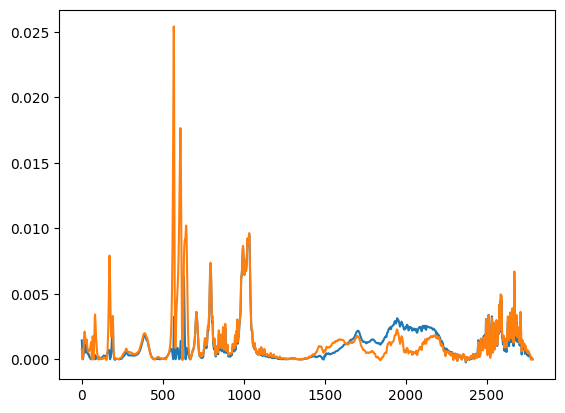

In [26]:
plt.plot(corrections_dict[comp][0]["absorbance"])
plt.plot(corrections_dict_stored[comp][0]["absorbance"])

In [12]:
tau_min, tau_max = 1e-5, 0.25
corrections_dict = {}

sample_id = raw_spectra_dict[comp]["raw"].index.tolist()
Y = np.array(raw_spectra_dict[comp]["raw"])

distribute_args = [
                (y, mu, W[:, :chat_cv], tau_min, tau_max, loss, sid)
                for y, sid in zip(Y, sample_id)
            ]

In [16]:
res = distribute_veb(distribute_args[0])

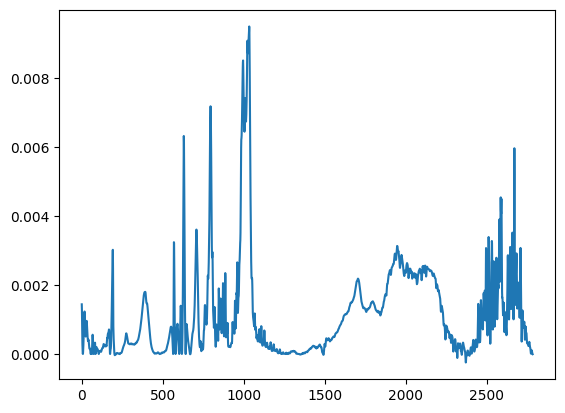

In [19]:
plt.plot(res["absorbance"])

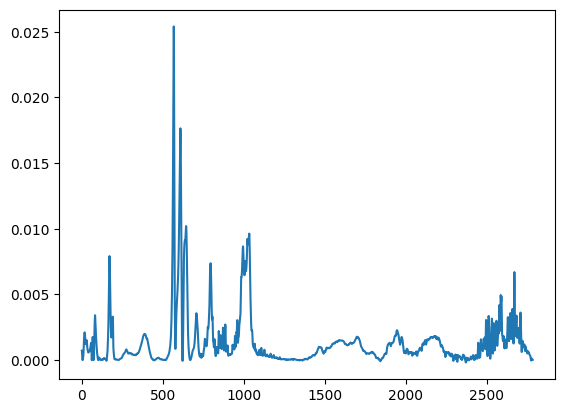

In [25]:
plt.plot(corrections_dict["Malonic Acid"][0]["absorbance"])

In [33]:
W.shape

(2785, 47)

In [22]:
y = np.array(raw_spectra_dict["Malonic Acid"]["raw"].iloc[3])

In [25]:
ncomp = loo_pca(Z)[1]
mu,_,_,W = pca(Z)
    
W = W[:,:ncomp]
mod = VEB(c = W.shape[1])
mod.fit(y, mu, W)

In [30]:
mod.tau

np.float64(0.2063433227276364)

In [27]:
mod.map(y, mu, W)

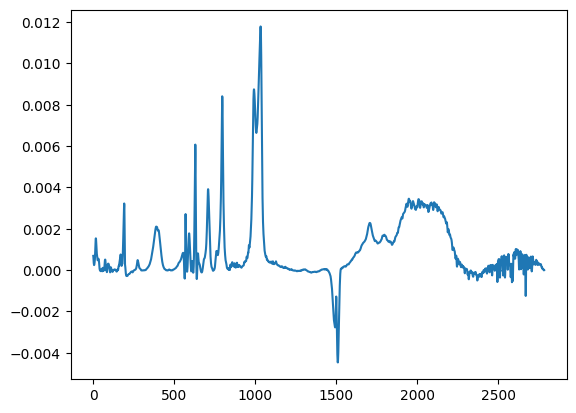

In [29]:
plt.plot(mod.absorbance)

{'sample_id': '01172.dpt',
 'absorbance': array([ 8.35632792e-05,  1.40374329e-04,  1.60607232e-04, ...,
        -3.37764645e-04, -3.31539408e-04, -3.17057275e-04], shape=(2785,)),
 'time': 20.439770460128784,
 'tau': np.float64(0.18856795948698746),
 'c': 47,
 'sigma_hat': np.float64(0.0002631062438199906),
 'nu': array([ -5.02360192,  -4.09407088,   8.62809982,  -5.09891573,
         11.15488308,   6.72208556, -22.3595294 , -16.28128447,
         19.78905442,  17.13632895,   1.1877687 , -10.83697334,
         -5.25906123,   1.5771795 ,   7.77673958,  -3.34127555,
          8.95541712,   3.54857074,   4.23028999,   2.74849377,
         -0.12824872,   2.44717028,   6.2388314 ,  11.05550577,
          6.14546655,   3.08924627,  -1.47694363,   1.57449831,
         -1.47592458,  -1.34741506,   0.09292179,  -0.54859907,
         -0.58774524,  -0.18049425,   0.09719457,   0.30644623,
          0.91768937,  -0.48370139,   0.35359866,  -0.95120269,
          0.28316737,   0.25903556,  -0.0685

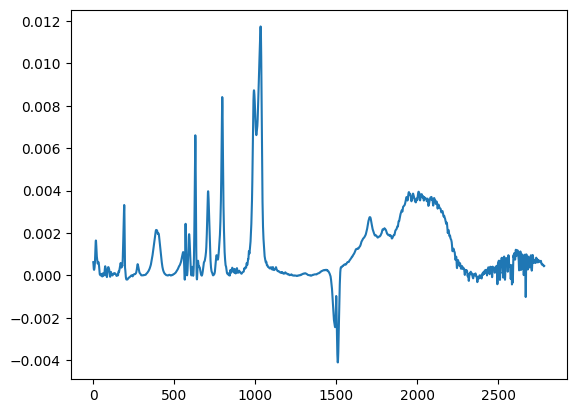

In [14]:
plt.plot(corrections_dict["Malonic Acid"][3]["absorbance"])

### KL divergence of LOO blanks

In [23]:
Z = np.array(blanks_dict["2011"])
ncomp = 47
blank_KL = []

In [285]:
def compute_latent_KL_divergence(nu,d):
    return (np.sum(nu**2 + d**2 - 2*np.log(d) - 1)/2)/nu.shape[0]

In [286]:
for i in tqdm(range(len(blank_KL),Z.shape[0])):
    y = Z[i,:]
    Zloo = np.delete(Z, i, axis=0)
    
    ncomp = loo_pca(Zloo)[1]
    mu,_,_,W = pca(Zloo, ncomp)
    
    mod = VEB(c = W.shape[1])
    mod.fit(y, mu, W)
    nu = mod.nu
    d = mod.d
    
    blank_KL.append(compute_latent_KL_divergence(nu,d))
    
blank_KL = np.array(blank_KL)

  0%|          | 0/54 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [287]:
max_blank_KL = np.max(blank_KL)

ValueError: zero-size array to reduction operation maximum which has no identity

In [288]:
KL = []
Mdists = []
zvals = []
cors = []
peak_val = []
all_corrections = []
sample_names = []

for comp in ref_dict:
    sample_names.append(np.array(raw_spectra_dict[comp]["raw"].index))
    
    with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
        corrections_dict = pickle.load(f)
    corrections_dict = corrections_dict[comp]

    for k in range(len(corrections_dict)):
        estimated_abs = corrections_dict[k]["absorbance"]
        cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
        peak_val.append(np.max(estimated_abs))
        all_corrections.append(estimated_abs)

    nu = np.array([i["nu"] for i in corrections_dict])
    d = np.array([i["d"] for i in corrections_dict])
    x = np.array([i["x"] for i in corrections_dict])

    
    for i in range(nu.shape[0]):
        KL.append(compute_latent_KL_divergence(nu[i,:],d[i,:]))
        Mdists.append(np.mean((x[i,:]**2)))
        zvals.append(np.mean(nu[i,:]/d[i,:]))

KL = np.array(KL)
Mdists = np.array(Mdists)
zvals = np.array(zvals)
cors = np.array(cors)        
peak_val = np.array(peak_val)
sample_names = np.concatenate(sample_names)


df = pd.DataFrame({"Sample": sample_names,"KL":KL,"Mdists":Mdists,"Zvals":zvals,"Peak":peak_val,"Correlation":cors})
df.set_index("Sample", inplace=True)
df.to_csv("veb_pb_info.csv")

In [289]:
component_KLs = []
component_Mdists = []
component_zvals = []

sample_names = []

for comp in ref_dict:
    sample_names.append(np.array(raw_spectra_dict[comp]["raw"].index))
    
    with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
        corrections_dict = pickle.load(f)
    corrections_dict = corrections_dict[comp]
    
    nu = np.array([i["nu"] for i in corrections_dict])
    d = np.array([i["d"] for i in corrections_dict])
    x = np.array([i["x"] for i in corrections_dict])
    
    component_KLs.append((nu**2 + d**2 - 2*np.log(d) - 1)/2)
    component_Mdists.append(x**2)
    component_zvals.append(nu/d)

sample_names = np.concatenate(sample_names)
component_KLs = pd.DataFrame(np.vstack(component_KLs))
component_KLs.index = sample_names
component_KLs.to_csv("veb_pb_component_KLs.csv")

component_Mdists = pd.DataFrame(np.vstack(component_Mdists))
component_Mdists.index = sample_names
component_Mdists.to_csv("veb_pb_component_Mdists.csv")

component_zvals = pd.DataFrame(np.vstack(component_zvals))
component_zvals.index = sample_names
component_zvals.to_csv("veb_pb_component_zvals.csv")

Text(0, 0.5, 'Correlation')

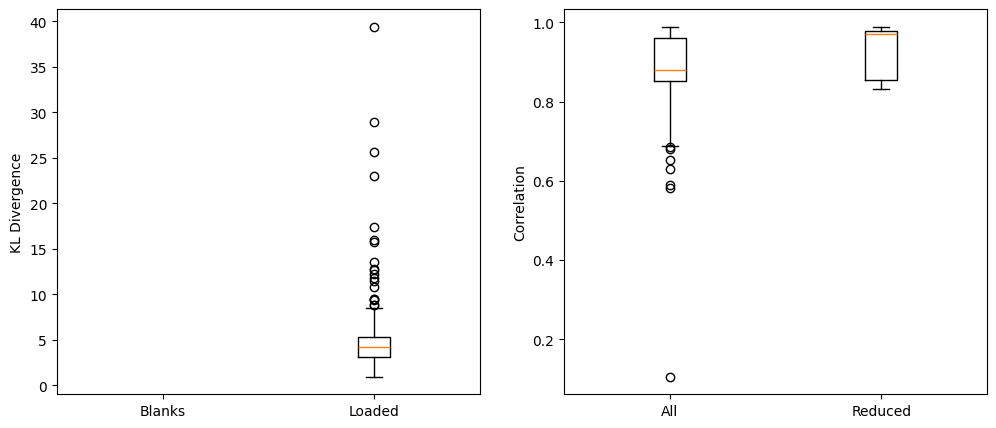

In [290]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([blank_KL,KL], tick_labels=["Blanks", "Loaded"])
axes[0].set_ylabel("KL Divergence")
# plt.ylabel("KL Divergence")
# plt.show()

axes[1].boxplot([cors,cors[KL <= max_blank_KL]], tick_labels=["All", "Reduced"])
axes[1].set_ylabel("Correlation")
# plt.ylabel("Correlation")
# plt.show()

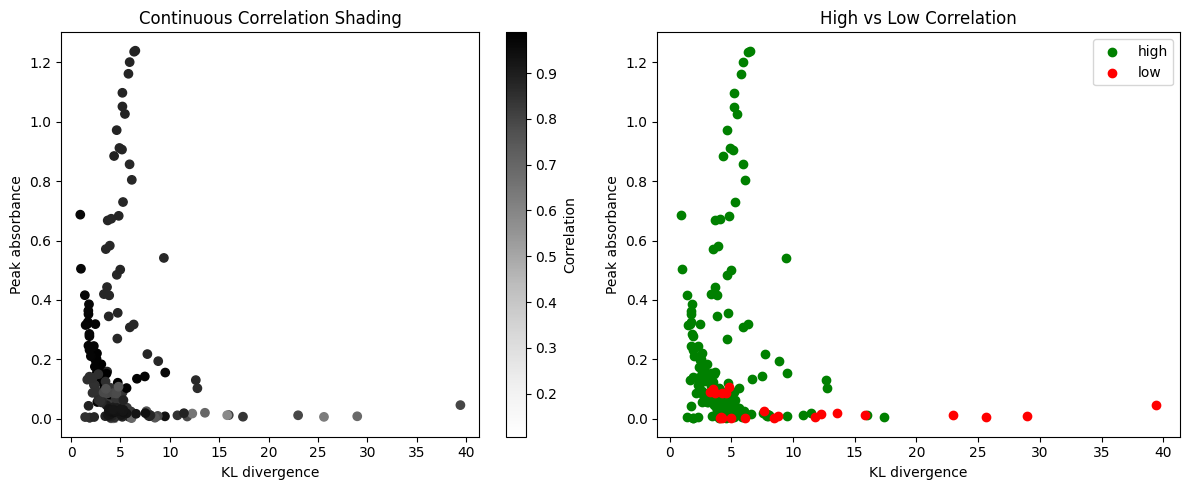

In [291]:
good_cors = np.where(cors >= 0.8)[0]
bad_cors = np.where(cors < 0.8)[0]

# Create two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Left Plot: Continuous grayscale coloring -----
sc1 = axes[0].scatter(KL, peak_val, c=cors, cmap="Greys")
axes[0].set_xlabel("KL divergence")
axes[0].set_ylabel("Peak absorbance")
axes[0].set_title("Continuous Correlation Shading")
cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Correlation")

# ----- Right Plot: Thresholded binary coloring -----
axes[1].scatter(KL[good_cors], peak_val[good_cors], c="g", label="high")
axes[1].scatter(KL[bad_cors], peak_val[bad_cors], c="r", label="low")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Peak absorbance")
axes[1].set_title("High vs Low Correlation")
axes[1].legend()

plt.tight_layout()
plt.show()

In [292]:
KL[38+39]

np.float64(9.5384263402046)

In [298]:
np.round(KL[38+39],2)

np.float64(9.54)

In [297]:
np.round(KL[38+40],2)

np.float64(2.64)

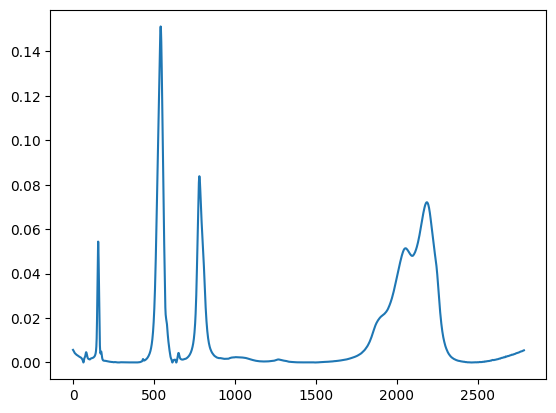

In [302]:
plt.plot(all_corrections[38+40])

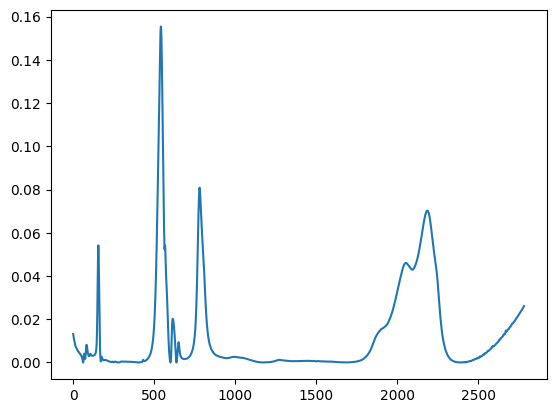

In [303]:
plt.plot(all_corrections[38+39])

In [216]:
pd.DataFrame({
    "KL Divergence": KL[bad_cors],
    "Peak Value": peak_val[bad_cors],
    "Correlation": cors[bad_cors],
    
})

,KL Divergence,Peak Value,Correlation
0,4.190595,0.006086,0.679882
1,39.417872,0.045839,0.798180
2,8.778272,0.009492,0.790134
3,11.763109,0.007388,0.786801
4,25.607564,0.006249,0.629196
5,22.989784,0.011611,0.792990
6,28.974558,0.008217,0.689270
7,15.809986,0.011846,0.582010
8,12.276878,0.017479,0.653690
9,7.636269,0.025355,0.759752


Index(['01455.dpt', '01456.dpt', '01457.dpt', '01458.dpt', '01459.dpt'], dtype='object', name='Sample')

In [227]:
pfte_corrections = pd.read_csv(CORRECTIONS_DIR / "sigma_tau_corrections.csv",index_col=0)

In [232]:
wn = pfte_corrections.columns.astype(float).to_numpy()

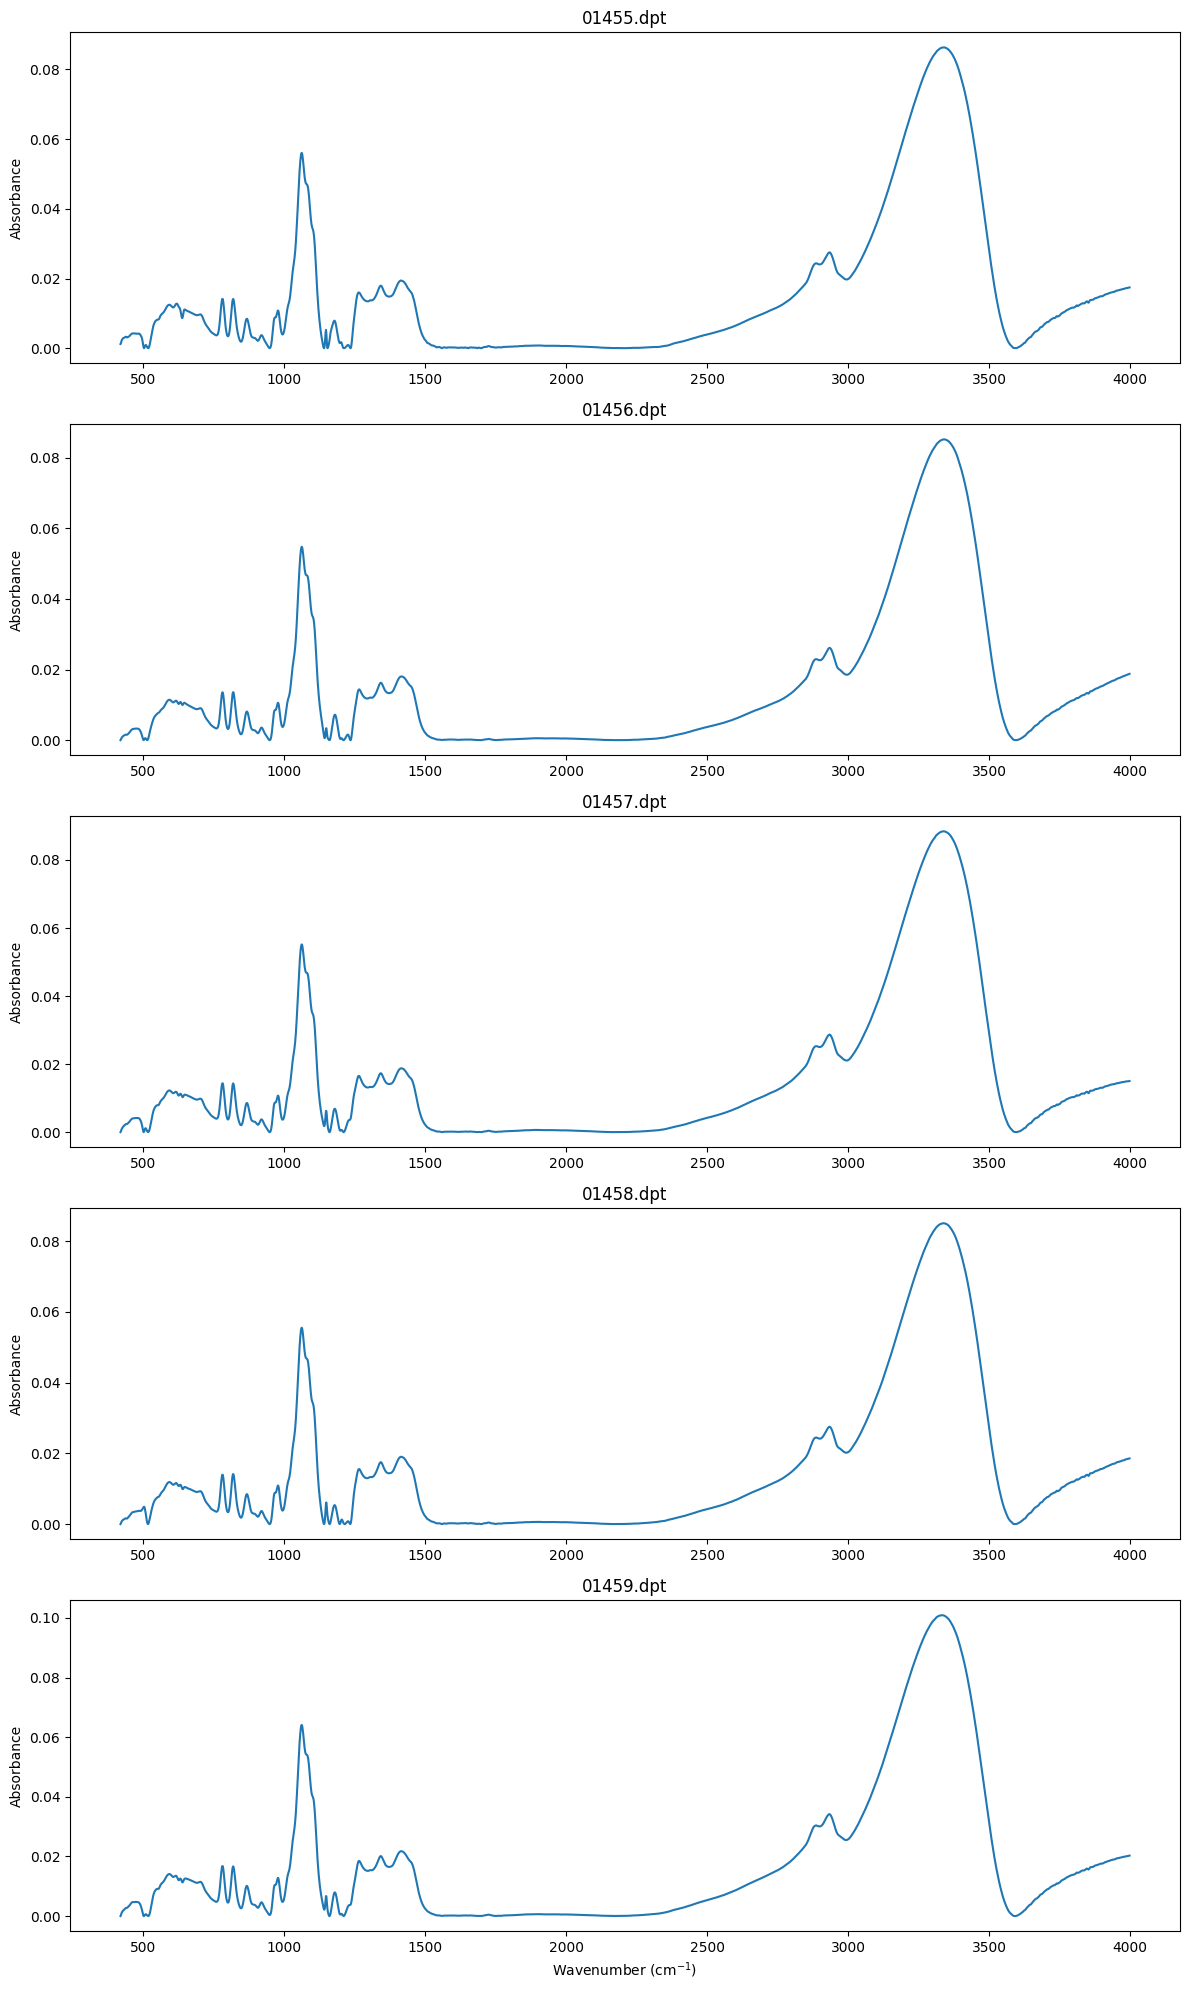

In [243]:
idx = df.iloc[bad_cors[12:17],:].index
fig, axes = plt.subplots(len(idx), 1, figsize=(12, 20))

for i in range(len(idx)):
    axes[i].plot(wn,np.array(pfte_corrections.loc[idx[i]]))
    axes[i].set_title(f"{idx[i]}")
    axes[i].set_ylabel("Absorbance")
axes[i].set_xlabel("Wavenumber (cm$^{-1}$)")
plt.tight_layout()
plt.savefig("fructose.png")

In [244]:
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "airmon" / "veb" / "pb"
RAW_DIR = REPO_ROOT / "data" / "raw" / "airmon"

tau_min, tau_max = 1e-5, 0.25

names = [
        "ambient_measurements",
        "ammonium_nitrate_calibration",
        "ammonium_sulphate_calibration",
        "athens_data",
        "japan",
    ]

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
        corrections_dict = pickle.load(f)

In [ ]:
KL = []
Mdists = []
zvals = []
peak_val = []
sample_names = []
campaign = []

for name in names:
    nu = np.array([i["nu"] for i in corrections_dict[name]])
    d = np.array([i["d"] for i in corrections_dict[name]])
    x = np.array([i["x"] for i in corrections_dict[name]])
    A = np.array([i["absorbance"] for i in corrections_dict[name]])
    
    for i in range(nu.shape[0]):
            KL.append(compute_latent_KL_divergence(nu[i,:],d[i,:]))
            Mdists.append(np.mean((x[i,:]**2)))
            zvals.append(np.mean(nu[i,:]/d[i,:]))      
            peak_val.append(np.max(A[i,:]))
            campaign.append(name)          

    sample_names.append(np.array(pd.read_csv(CORRECTIONS_DIR / f"{name}_corrections.csv",index_col=0).index))
    
KL = np.array(KL)
Mdists = np.array(Mdists)
zvals = np.array(zvals)    
peak_val = np.array(peak_val)
sample_names = np.concatenate(sample_names)
campaign = np.array(campaign)

In [270]:
pd.DataFrame({
    "Campaign": campaign,
    "Sample": sample_names,
    "KL": KL,
    "Mdists": Mdists,
    "Zvals": zvals,
    "Peak": peak_val
}).to_csv(CORRECTIONS_DIR / "airmon_veb_pb_info.csv")

In [271]:
pd.DataFrame({
    "Campaign": campaign,
    "Sample": sample_names,
    "KL": KL,
    "Mdists": Mdists,
    "Zvals": zvals,
    "Peak": peak_val
})

,Campaign,Sample,KL,Mdists,Zvals,Peak
0,ambient_measurements,20250614_Ambient_10_B,21.234775,36.369887,88.359399,0.001236
1,ambient_measurements,20250614_Ambient_11_A,34.490298,64.145204,-21.853241,0.001388
2,ambient_measurements,20250614_Ambient_12_B,33.414538,61.013757,212.989968,0.001926
3,ambient_measurements,20250614_Ambient_13_A,31.668446,57.824066,-1.087514,0.002178
4,ambient_measurements,20250614_Ambient_14_B,15.357747,24.294792,427.511185,0.001652
...,...,...,...,...,...,...
451,japan,20250901_exp01_5_A,5.437393,5.992958,95.771633,0.000770
452,japan,20250901_exp01_6_B,6.417777,8.238294,282.667892,0.000934
453,japan,20250901_exp01_7_A,5.847917,6.894746,148.064614,0.000917
454,japan,20250901_exp01_8_B,6.667999,9.193834,177.276863,0.001558


In [263]:
KL.shape

(456,)

In [264]:
sample_names.shape

(456,)

In [132]:
A = np.array([i["absorbance"] for i in corrections_dict[names[4]]])

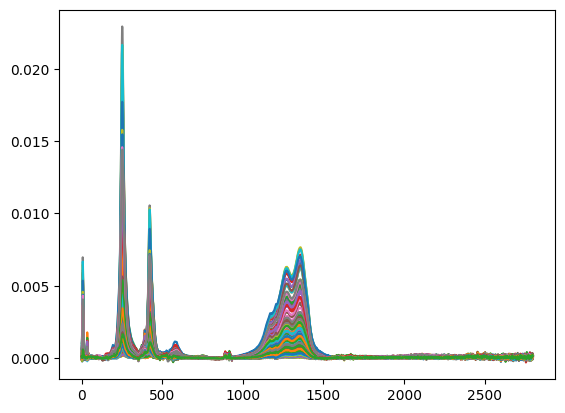

In [133]:
for a in A:
    plt.plot(a)

In [21]:
bad_cors

array([  0,   1,  88,  89,  96,  97,  98, 101, 102, 103, 117, 125, 144,
       145, 146, 147, 148, 149, 150, 154, 155, 156])

,KL Divergence,Peak Value,Correlation
0,4.190595,0.006086,0.679882
1,39.417872,0.045839,0.798180
2,8.778272,0.009492,0.790134
3,11.763109,0.007388,0.786801
4,25.607564,0.006249,0.629196
5,22.989784,0.011611,0.792990
6,28.974558,0.008217,0.689270
7,15.809986,0.011846,0.582010
8,12.276878,0.017479,0.653690
9,7.636269,0.025355,0.759752


In [38]:
bad_cors[12:17]

array([144, 145, 146, 147, 148])

In [41]:
cors[bad_cors[12:17]]

array([0.79009852, 0.79444419, 0.78690759, 0.78256401, 0.76940081])

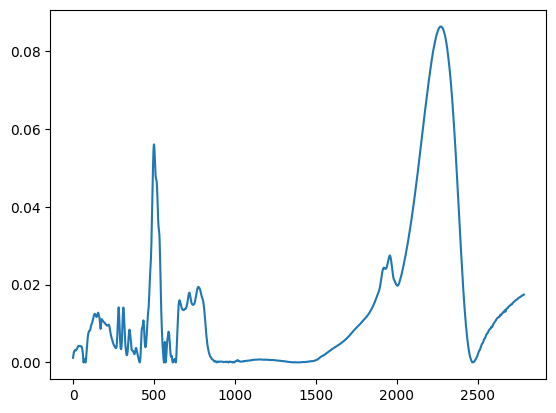

In [45]:
plt.plot(all_corrections[144])

In [24]:
peak_val[bad_cors]

array([0.00608628, 0.04583865, 0.00949233, 0.00738801, 0.00624882,
       0.01161137, 0.00821717, 0.01184593, 0.01747899, 0.025355  ,
       0.0200217 , 0.00338182, 0.08634391, 0.08518912, 0.08843128,
       0.08508478, 0.10088123, 0.10786335, 0.0012841 , 0.00195125,
       0.0013736 , 0.00200769])

### 12-Tricosanone

In [ ]:
comp = "12-Tricosanone"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)/nu.shape[1]

In [74]:
cors[KL <= max_blank_KL]

array([0.87399459, 0.87467641, 0.87418179])

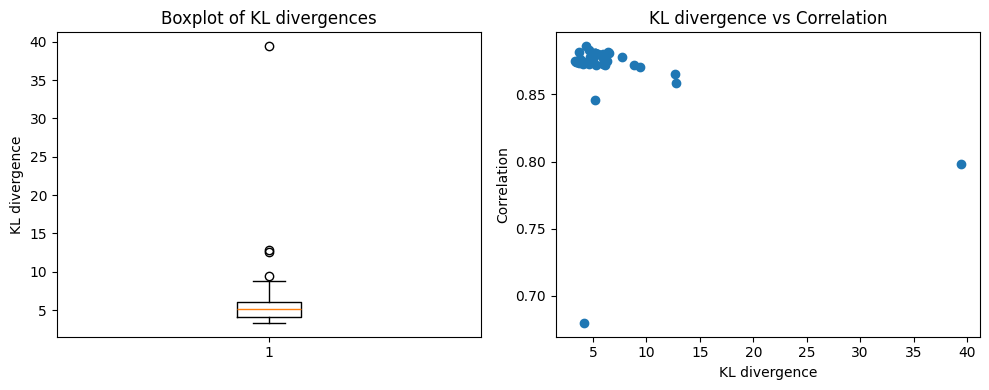

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

In [168]:
np.flip(np.argsort(KL))

array([ 1,  4,  5, 19,  7,  8, 38, 37, 11, 26, 10, 36, 27, 34, 31, 25,  2,
       33, 35, 29, 18, 28, 24, 13,  9, 17, 32, 30,  0, 23, 21, 14, 12, 22,
        3, 16, 20,  6, 15])

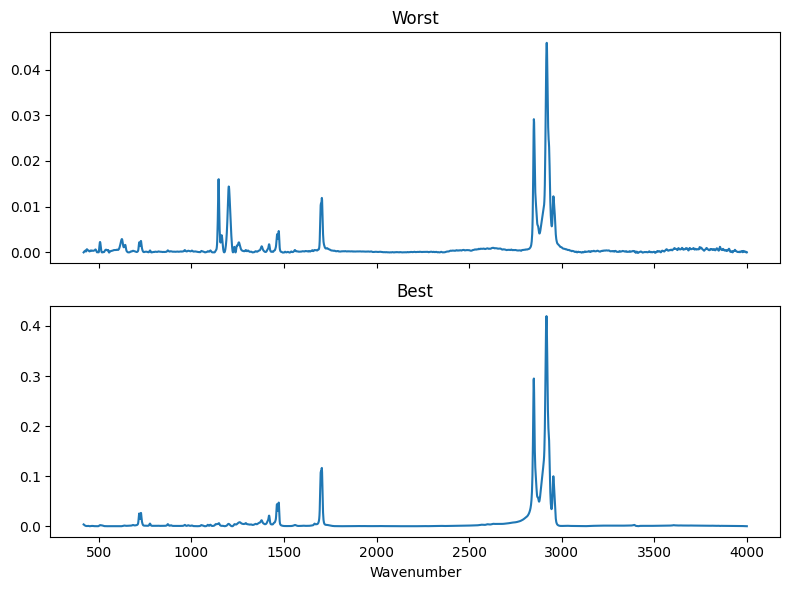

In [169]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[1]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[15]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

### SO4

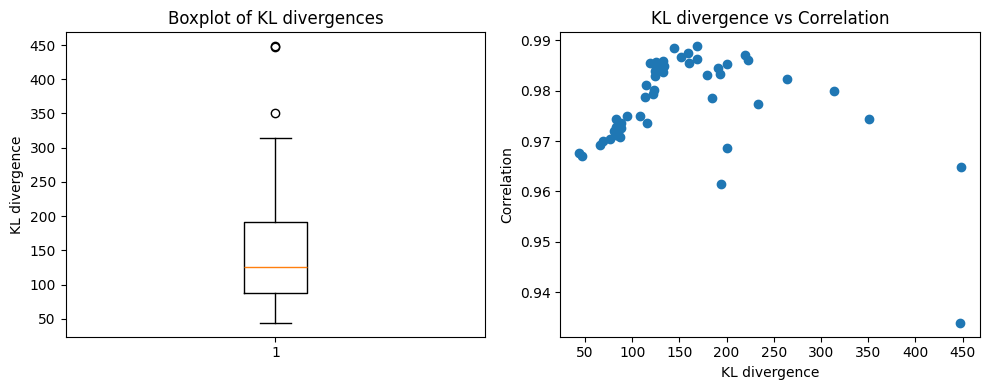

In [179]:
comp = "Ammonium sulfate"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

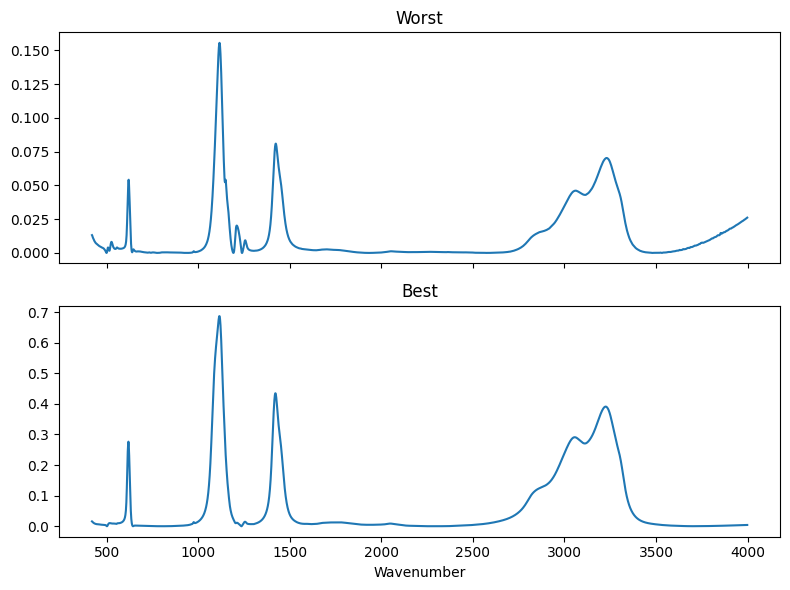

In [180]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

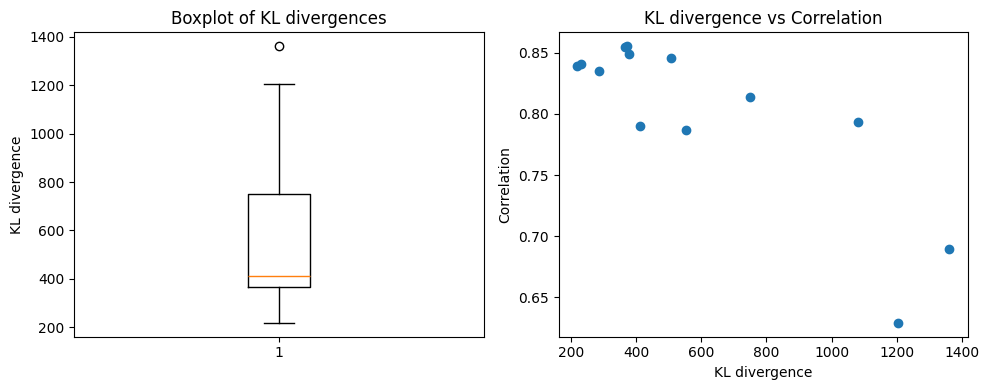

In [182]:
comp = "Malonic Acid"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

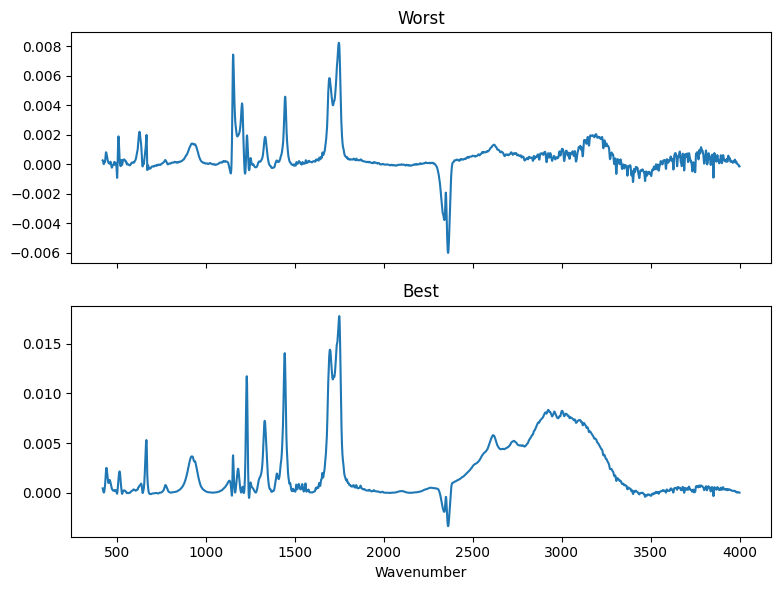

In [183]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

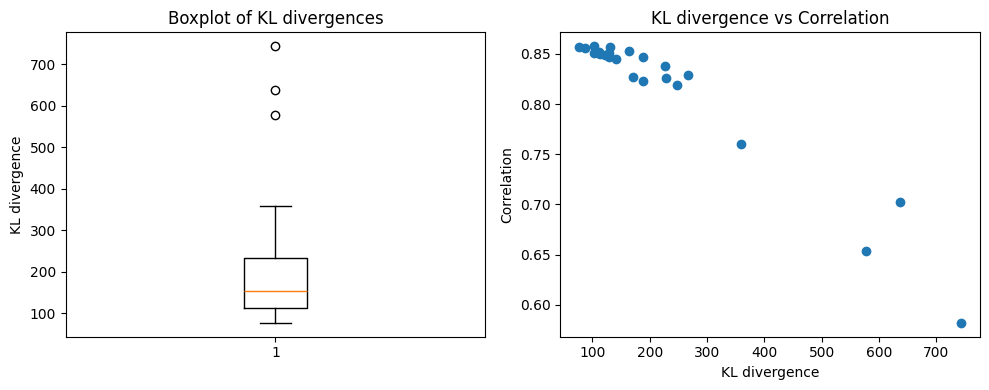

In [184]:
comp = "Suberic Acid"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

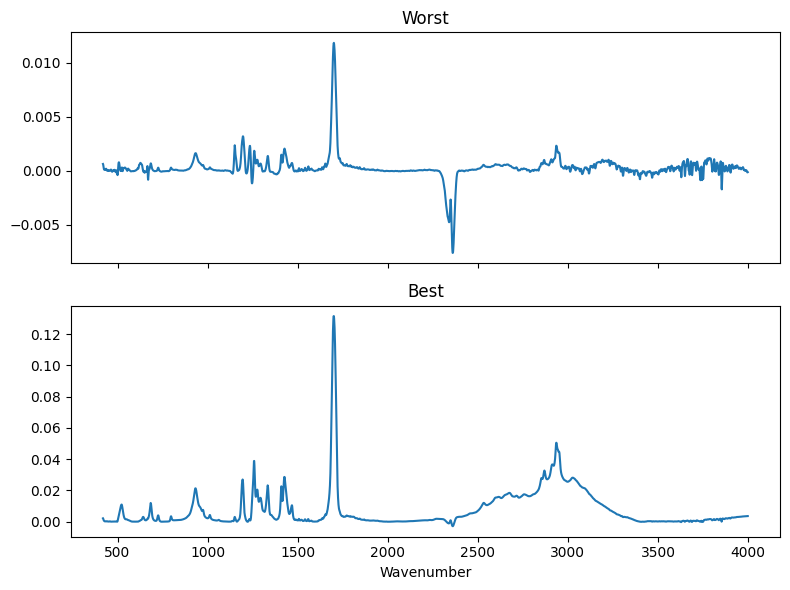

In [185]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

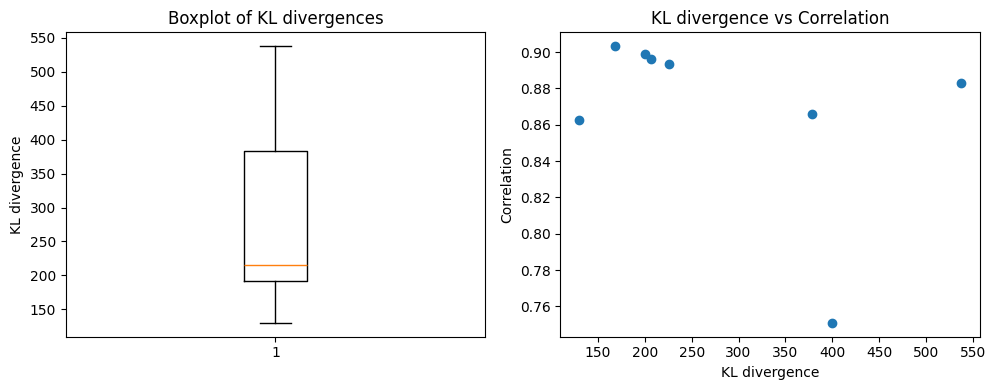

In [186]:
comp = "D-Glucose"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

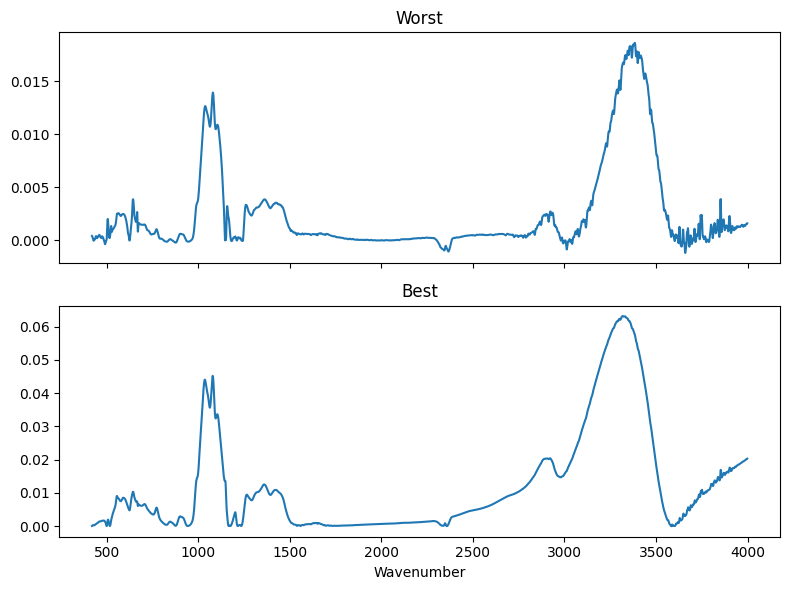

In [187]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

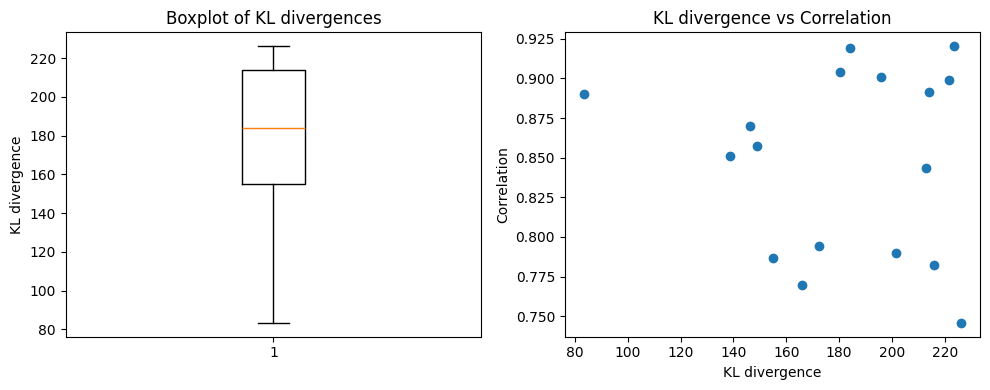

In [188]:
comp = "fructose"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

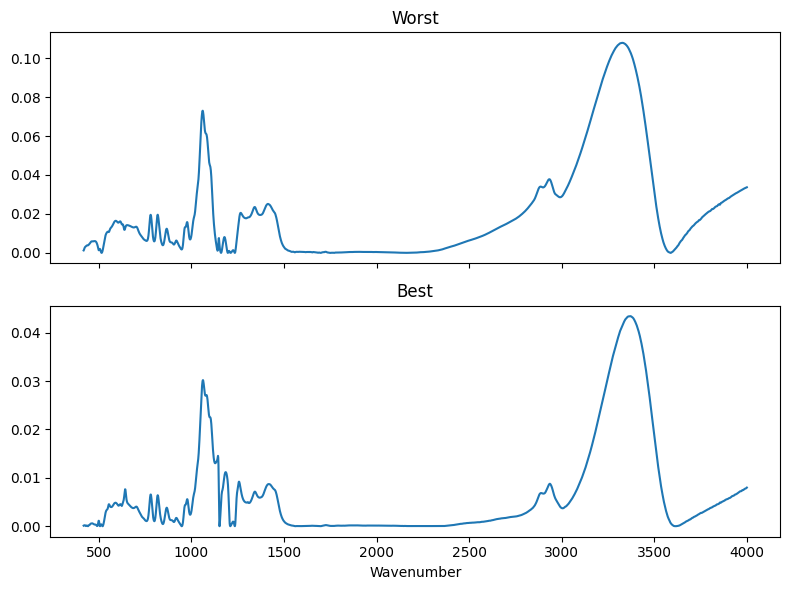

In [189]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

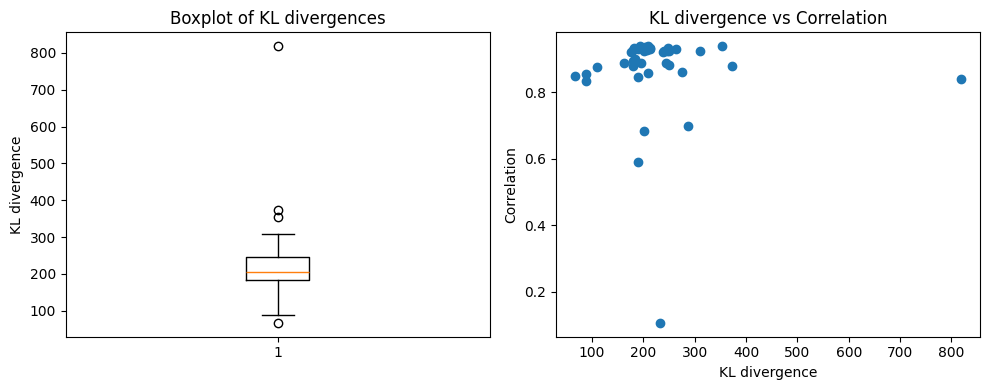

In [190]:
comp = "levoglucosan"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

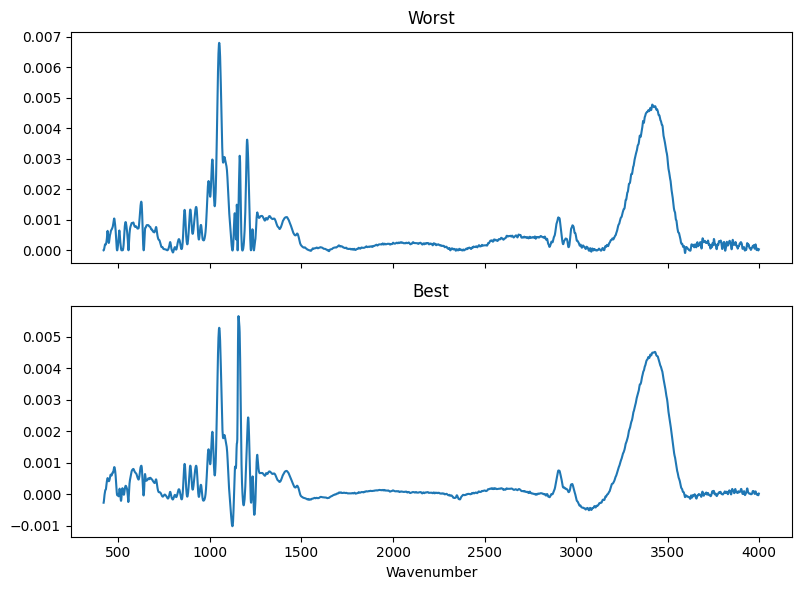

In [191]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()